# Sentiment Analysis using NLP Pipeline & ML Models - Assignment 2

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
!unzip imdb-dataset-of-50k-movie-reviews.zip

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
100% 25.7M/25.7M [00:03<00:00, 8.93MB/s]

Archive:  imdb-dataset-of-50k-movie-reviews.zip
  inflating: IMDB Dataset.csv        


In [2]:
! pip install nltk scikit-learn seaborn wordcloud -q

import re
import string
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [3]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
print("Shape of dataset:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution:\n", df['sentiment'].value_counts())

Shape of dataset: (50000, 2)

Column names: ['review', 'sentiment']

Missing values:
 review       0
sentiment    0
dtype: int64

Class distribution:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64


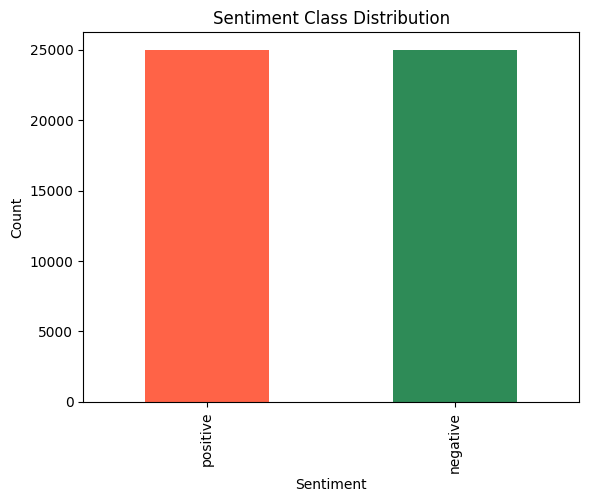

In [5]:
df['sentiment'].value_counts().plot(kind='bar', color=['tomato', 'seagreen'])
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [6]:
print("\nSample positive review:\n")
print(df[df['sentiment'] == 'positive']['review'].iloc[0])

print("\nSample negative review:\n")
print(df[df['sentiment'] == 'negative']['review'].iloc[0])


Sample positive review:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of 

In [7]:
df['label'] = df['sentiment'].map({'negative': 0, 'positive': 1})
df[['sentiment', 'label']].head()

,sentiment,label
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1


In [8]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text_basic(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_v1(text):
    text = clean_text_basic(text)
    tokens = word_tokenize(text)
    return " ".join(tokens)

def preprocess_v2(text):
    text = clean_text_basic(text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

def preprocess_v3(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)

    text = re.sub(r"n't", " not", text)
    text = re.sub(r"\'re", " are", text)
    text = re.sub(r"\'s", " is", text)
    text = re.sub(r"\'d", " would", text)
    text = re.sub(r"\'ll", " will", text)
    text = re.sub(r"\'t", " not", text)
    text = re.sub(r"\'ve", " have", text)
    text = re.sub(r"\'m", " am", text)

    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = word_tokenize(text)

    processed_tokens = []
    i = 0
    while i < len(tokens):
        if tokens[i] == 'not' and i + 1 < len(tokens):
            combined_word = 'not_' + tokens[i + 1]
            processed_tokens.append(combined_word)
            i += 2
        else:
            if tokens[i] not in stop_words:
                lemma = lemmatizer.lemmatize(tokens[i])
                processed_tokens.append(lemma)
            i += 1

    return " ".join(processed_tokens)

In [9]:
df['clean_review_v1'] = df['review'].apply(preprocess_v1)
df['clean_review_v2'] = df['review'].apply(preprocess_v2)
df['clean_review_v3'] = df['review'].apply(preprocess_v3)

df[['review', 'clean_review_v3']].head()

,review,clean_review_v3
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


In [10]:
df['review_length_chars'] = df['review'].apply(len)
df['review_length_words'] = df['review'].apply(lambda x: len(str(x).split()))
df['exclamation_count'] = df['review'].apply(lambda x: str(x).count('!'))
df['question_count'] = df['review'].apply(lambda x: str(x).count('?'))

df[['review_length_chars', 'review_length_words', 'exclamation_count', 'question_count']].head()

,review_length_chars,review_length_words,exclamation_count,question_count
0,1761,307,0,0
1,998,162,1,0
2,926,166,0,1
3,748,138,2,0
4,1317,230,0,0


In [11]:
X = df['clean_review_v3']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 40000
Test size: 10000


In [12]:
bow_vectorizer = CountVectorizer(max_features=10000, ngram_range=(1, 2))
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("BoW train shape:", X_train_bow.shape)
print("TF-IDF train shape:", X_train_tfidf.shape)

BoW train shape: (40000, 10000)
TF-IDF train shape: (40000, 10000)


In [13]:
results = []

def evaluate_model(model, model_name, vectorizer_name, X_train_vec, X_test_vec, y_train, y_test):
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Vectorizer': vectorizer_name,
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    })

    return y_pred

In [14]:
lr_bow = LogisticRegression(max_iter=1000)
nb_bow = MultinomialNB()
dt_bow = DecisionTreeClassifier(max_depth=20, random_state=42)

evaluate_model(lr_bow, "Logistic Regression", "BoW", X_train_bow, X_test_bow, y_train, y_test)
evaluate_model(nb_bow, "Naive Bayes", "BoW", X_train_bow, X_test_bow, y_train, y_test)
evaluate_model(dt_bow, "Decision Tree", "BoW", X_train_bow, X_test_bow, y_train, y_test)

array([1, 1, 1, ..., 0, 1, 1])

In [15]:
lr_tfidf = LogisticRegression(max_iter=1000)
nb_tfidf = MultinomialNB()
dt_tfidf = DecisionTreeClassifier(max_depth=20, random_state=42)

y_pred_lr_tfidf = evaluate_model(lr_tfidf, "Logistic Regression", "TF-IDF", X_train_tfidf, X_test_tfidf, y_train, y_test)
evaluate_model(nb_tfidf, "Naive Bayes", "TF-IDF", X_train_tfidf, X_test_tfidf, y_train, y_test)
evaluate_model(dt_tfidf, "Decision Tree", "TF-IDF", X_train_tfidf, X_test_tfidf, y_train, y_test)

array([1, 1, 1, ..., 0, 1, 1])

In [16]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1 Score', ascending=False)
results_df

,Vectorizer,Model,Accuracy,Precision,Recall,F1 Score
3,TF-IDF,Logistic Regression,0.9024,0.895751,0.9108,0.903213
0,BoW,Logistic Regression,0.8822,0.880072,0.8850,0.882529
4,TF-IDF,Naive Bayes,0.8728,0.859985,0.8906,0.875025
1,BoW,Naive Bayes,0.8639,0.857395,0.8730,0.865127
2,BoW,Decision Tree,0.7521,0.717590,0.8314,0.770314
5,TF-IDF,Decision Tree,0.7505,0.720317,0.8190,0.766495


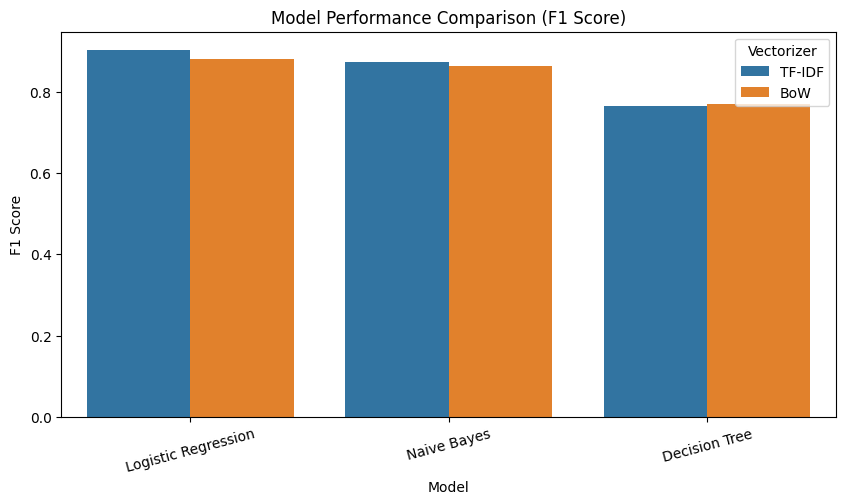

In [17]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='Model', y='F1 Score', hue='Vectorizer')
plt.title("Model Performance Comparison (F1 Score)")
plt.xticks(rotation=15)
plt.show()

In [18]:
param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_lr.fit(X_train_tfidf, y_train)

print("Best Parameters:", grid_lr.best_params_)
print("Best CV Score:", grid_lr.best_score_)

Best Parameters: {'C': 1, 'solver': 'liblinear'}
Best CV Score: 0.8972866734365045


In [19]:
best_lr = grid_lr.best_estimator_
best_pred = best_lr.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, best_pred))
print("Precision:", precision_score(y_test, best_pred))
print("Recall:", recall_score(y_test, best_pred))
print("F1 Score:", f1_score(y_test, best_pred))

Accuracy: 0.9011
Precision: 0.8945504623253984
Recall: 0.9094
F1 Score: 0.9019141128632352


In [20]:
print(classification_report(y_test, best_pred, target_names=['Negative', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



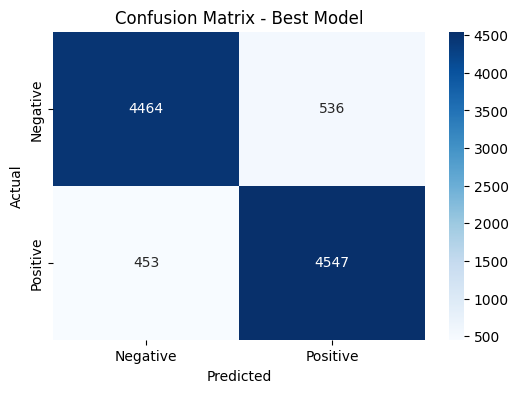

In [21]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title("Confusion Matrix - Best Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
coefficients = best_lr.coef_[0]

top_positive_idx = np.argsort(coefficients)[-20:]
top_negative_idx = np.argsort(coefficients)[:20]

top_positive_words = feature_names[top_positive_idx]
top_negative_words = feature_names[top_negative_idx]

print("Top Positive Words:\n", top_positive_words)
print("\nTop Negative Words:\n", top_negative_words)

Top Positive Words:
 ['fantastic' 'well' 'definitely' 'must see' 'superb' 'enjoyable' 'today'
 'enjoyed' 'fun' 'brilliant' 'favorite' 'one best' 'loved' 'best'
 'hilarious' 'wonderful' 'amazing' 'perfect' 'excellent' 'great']

Top Negative Words:
 ['worst' 'bad' 'awful' 'boring' 'waste' 'poor' 'terrible' 'not_even'
 'nothing' 'horrible' 'dull' 'worse' 'poorly' 'disappointing' 'fails'
 'unfortunately' 'stupid' 'instead' 'supposed' 'disappointment']


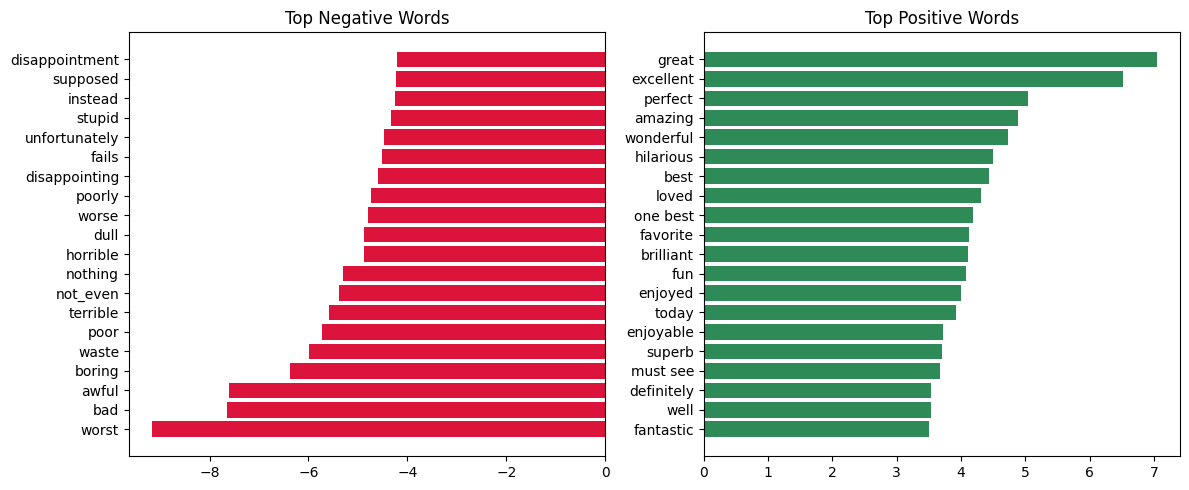

In [23]:
top_pos_scores = coefficients[top_positive_idx]
top_neg_scores = coefficients[top_negative_idx]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.barh(top_negative_words, top_neg_scores, color='crimson')
plt.title("Top Negative Words")

plt.subplot(1, 2, 2)
plt.barh(top_positive_words, top_pos_scores, color='seagreen')
plt.title("Top Positive Words")

plt.tight_layout()
plt.show()

In [24]:
error_df = pd.DataFrame({
    'Review': X_test,
    'Actual': y_test,
    'Predicted': best_pred
})

misclassified = error_df[error_df['Actual'] != error_df['Predicted']]
misclassified.head(10)

,Review,Actual,Predicted
39791,story bride fair amusing engaging one filmmake...,0,1
40714,little quentin seems mastered art cake eating ...,0,1
31882,film listed made not_the film available someth...,0,1
11840,known brad linaweaver florida state u early in...,0,1
48388,order enjoy fur imaginary portrait diane arbus...,0,1
20169,quite fan novelist screenwriter michael chabon...,0,1
26800,tenshu imprisoned sentenced death survives ele...,1,0
46536,ca not_believe comment show show genius sure n...,1,0
39806,seen branaghs hamlet branagh old speaks freque...,1,0
45621,lady gentleman really got winner actually not_...,1,0


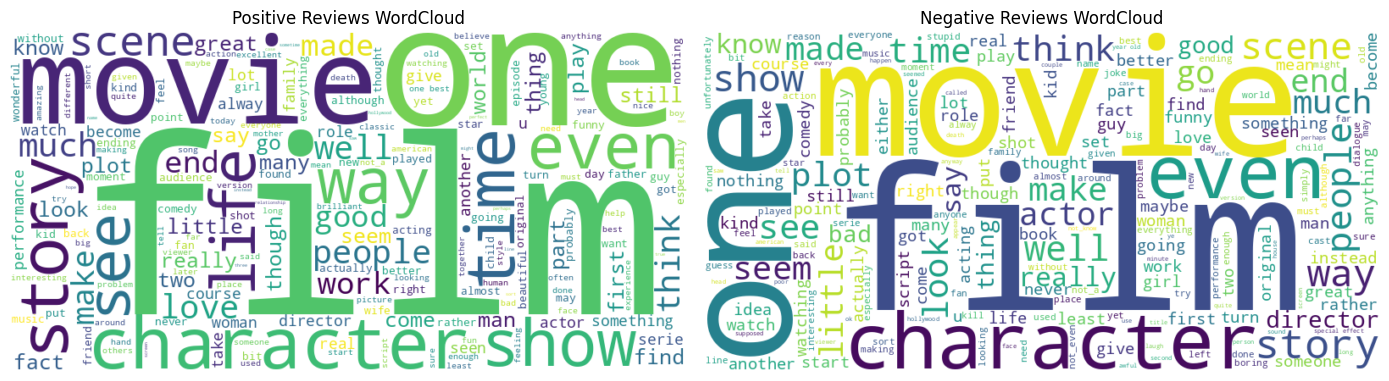

In [25]:
positive_text = " ".join(df[df['label'] == 1]['clean_review_v3'])
negative_text = " ".join(df[df['label'] == 0]['clean_review_v3'])

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
wc1 = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
plt.imshow(wc1, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Reviews WordCloud")

plt.subplot(1, 2, 2)
wc2 = WordCloud(width=800, height=400, background_color='white').generate(negative_text)
plt.imshow(wc2, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Reviews WordCloud")

plt.tight_layout()
plt.show()